# Nonlinear real second-order nudging test

This notebook tests the second condition of Theorem 5.1 for real-valued second-order systems. In this nonlinear case the adjoint field is the infinitesimal response of a nudged time-reversed trajectory, rather than the output of a single finite-amplitude run as in the linear reciprocal case.

The forward dynamics are

$$
M(p_M)\ddot u(t)+D(p_D)\dot u(t)+F(t,u(t);p_F)-f(t;p_f)=0,
\qquad
u(0)=u_0(p_0),
\qquad
\dot u(0)=v_0(p_0).
$$

The second part of Theorem 5.1 requires

$$
M^T=M,
\qquad
D=0,
\qquad
F_u(t,u(t);p_F)^T=F_u(t,u(t);p_F)
\quad \text{along the forward trajectory}.
$$

These are two distinct requirements. The condition $D=0$ lets the same hardware retrace the forward trajectory by initializing

$$
w(0)=u(T),
\qquad
\dot w(0)=-\dot u(T),
$$

and replaying explicit time dependence and drive as $T-\tau$. The tangent reciprocity condition $F_u^T=F_u$ then makes an infinitesimal perturbation of this reversed trajectory obey the adjoint equation.

The digital adjoint in reverse time $\tau=T-t$ satisfies

$$
M^T\ddot a(\tau)
+D^T\dot a(\tau)
+F_u(T-\tau,u(T-\tau);p_F)^T a(\tau)
+\theta_u[u(T-\tau),T-\tau]=0,
$$

with initial conditions

$$
M^T a(0)=-\psi_{\dot u}[u(T),\dot u(T)],
\qquad
M^T\dot a(0)+D^T a(0)=-\psi_u[u(T),\dot u(T)].
$$

The physical nudging experiment runs two reversed trajectories on the same hardware. The unnudged run is

$$
M\ddot w+D\dot w+F(T-\tau,w)-f(T-\tau)=0.
$$

The nudged run starts from the cost-derived adjoint initial perturbation and uses the source

$$
f(T-\tau)-\epsilon\,\theta_u[u(T-\tau),T-\tau].
$$

The physical adjoint estimate is

$$
a_{phys}(\tau)
=
\frac{w^\epsilon(\tau)-w(\tau)}{\epsilon}.
$$

If the theorem conditions hold, then $a_{phys}\to a$ as $\epsilon\to0$. The gradient is then evaluated from the overlap

$$
\frac{d\chi}{dp}
=
\int_0^T
 a(T-t)^T
\left[
M_p\ddot u(t)+D_p\dot u(t)+F_p(t,u(t))-f_p(t)
\right]dt,
$$

with boundary terms

$$
\frac{d\chi}{du_0}=-M^T\dot a(T)-D^T a(T),
\qquad
\frac{d\chi}{dv_0}=-M^T a(T).
$$

We test three cases:

- valid: $D=0$ and $F_u^T=F_u$;
- damping broken: $D\ne0$ but $F_u^T=F_u$;
- tangent broken: $D=0$ but $F_u^T\ne F_u$.

The digital adjoint should pass in all three cases. The nudged physical adjoint should pass only in the valid case.


### Setup
Imports, time grid, tolerances, and the nudging amplitude $\epsilon=10^{-6}$. `D0` is the damping shape, scaled by the parameter `damp`. `S_skew` is the antisymmetric matrix used to build the nonreciprocal force.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson

T = 5.0
Nt = 801
rtol = 1e-10
atol = 1e-12
nudging_epsilon = 1e-6

t_grid = np.linspace(0.0, T, Nt)

initial_condition_names = ["u0[0]", "u0[1]", "v0[0]", "v0[1]"]
mass_parameter_names = ["m0", "m1"]
damping_parameter_names = ["damp"]
force_parameter_names = ["k0", "k1", "kc", "alpha", "mu", "Omega", "g", "eta"]
drive_parameter_names = ["A0", "A1", "omega_f"]
parameter_names = (
    initial_condition_names
    + mass_parameter_names
    + damping_parameter_names
    + force_parameter_names
    + drive_parameter_names
)

D0 = np.diag([0.08, 0.11])
S_skew = np.array([[0.0, 1.0], [-1.0, 0.0]])

q_traj = 0.20
q_T = 0.70
q_V = 0.12
u_target = np.array([0.08, -0.06])
v_target = np.array([0.01, 0.00])

np.set_printoptions(precision=6, suppress=False)


### Nonlinear force, Jacobian, and derivatives
$F$ has three parts:
- a symmetric time-dependent linear part $K_s(t)u$;
- a cubic coupling $g(u_0-u_1)^3(1,-1)$, which is the gradient of a potential, so its Jacobian is symmetric;
- $\eta S u$, which makes $F_u$ nonsymmetric.

`F_u` is the analytic Jacobian and is used only by the digital adjoint and the diagnostics. The physical experiment never calls it.

In [2]:
def make_parameters(damp, eta):
    return np.array(
        [0.45, -0.18, 0.00, 0.16]
        + [1.00, 1.20]
        + [damp]
        + [1.30, 1.80, 0.45, 0.12, 0.10, 0.90, 0.55, eta]
        + [0.08, -0.05, 0.75],
        dtype=float,
    )


def unpack(p):
    return dict(zip(parameter_names, p))


def initial_conditions(p):
    p = unpack(p)
    u0 = np.array([p["u0[0]"], p["u0[1]"]], dtype=float)
    v0 = np.array([p["v0[0]"], p["v0[1]"]], dtype=float)
    return u0, v0


def M(p):
    p = unpack(p)
    return np.diag([p["m0"], p["m1"]])


def D(p):
    return unpack(p)["damp"] * D0


def K_symmetric(t, p):
    p = unpack(p)
    ct = np.cos(p["Omega"] * t)
    st = np.sin(p["Omega"] * t)
    return np.array(
        [
            [p["k0"] + p["kc"] + p["alpha"] * ct, -p["kc"] + p["mu"] * st],
            [-p["kc"] + p["mu"] * st, p["k1"] + p["kc"] - p["alpha"] * ct],
        ],
        dtype=float,
    )


def F(t, u, p):
    p_dict = unpack(p)
    du = u[0] - u[1]
    conservative = K_symmetric(t, p) @ u + p_dict["g"] * du**3 * np.array([1.0, -1.0])
    nonreciprocal = p_dict["eta"] * (S_skew @ u)
    return conservative + nonreciprocal


def F_u(t, u, p):
    p_dict = unpack(p)
    du = u[0] - u[1]
    kerr_tangent = 3.0 * p_dict["g"] * du**2 * np.array([[1.0, -1.0], [-1.0, 1.0]])
    return K_symmetric(t, p) + kerr_tangent + p_dict["eta"] * S_skew


def drive(t, p):
    p = unpack(p)
    return np.array([p["A0"] * np.sin(p["omega_f"] * t), p["A1"] * np.cos(p["omega_f"] * t)])


def dM_dp(name):
    if name == "m0":
        return np.array([[1.0, 0.0], [0.0, 0.0]])
    if name == "m1":
        return np.array([[0.0, 0.0], [0.0, 1.0]])
    raise KeyError(name)


def dF_dp(t, u, p, name):
    p_dict = unpack(p)
    ct = np.cos(p_dict["Omega"] * t)
    st = np.sin(p_dict["Omega"] * t)
    du = u[0] - u[1]

    if name == "k0":
        return np.array([u[0], 0.0])
    if name == "k1":
        return np.array([0.0, u[1]])
    if name == "kc":
        return np.array([u[0] - u[1], -u[0] + u[1]])
    if name == "alpha":
        return np.array([ct * u[0], -ct * u[1]])
    if name == "mu":
        return np.array([st * u[1], st * u[0]])
    if name == "Omega":
        dct = -t * np.sin(p_dict["Omega"] * t)
        dst = t * np.cos(p_dict["Omega"] * t)
        return np.array(
            [
                p_dict["alpha"] * dct * u[0] + p_dict["mu"] * dst * u[1],
                p_dict["mu"] * dst * u[0] - p_dict["alpha"] * dct * u[1],
            ]
        )
    if name == "g":
        return du**3 * np.array([1.0, -1.0])
    if name == "eta":
        return S_skew @ u
    raise KeyError(name)


def drive_dp(t, p, name):
    p_dict = unpack(p)
    wt = p_dict["omega_f"] * t
    if name == "A0":
        return np.array([np.sin(wt), 0.0])
    if name == "A1":
        return np.array([0.0, np.cos(wt)])
    if name == "omega_f":
        return np.array([p_dict["A0"] * t * np.cos(wt), -p_dict["A1"] * t * np.sin(wt)])
    raise KeyError(name)


### Cost and forward solve
Running and terminal costs as in the linear notebook. The forward model integrates $M\ddot u+D\dot u+F(t,u)-f=0$ as a first-order system.

In [3]:
def u_reference(t):
    return np.array([0.06 * np.sin(0.40 * t), -0.04 * np.cos(0.60 * t)])


def theta_value(u, t):
    return 0.5 * q_traj * np.sum((u - u_reference(t)) ** 2)


def theta_u(u, t):
    return q_traj * (u - u_reference(t))


def psi_value(u, v):
    return 0.5 * q_T * np.sum((u - u_target) ** 2) + 0.5 * q_V * np.sum((v - v_target) ** 2)


def psi_u(u, v):
    return q_T * (u - u_target)


def psi_v(u, v):
    return q_V * (v - v_target)


def acceleration(t, u, v, p):
    return np.linalg.solve(M(p), drive(t, p) - D(p) @ v - F(t, u, p))


def forward_rhs(t, z, p):
    u = z[:2]
    v = z[2:]
    return np.r_[v, acceleration(t, u, v, p)]


def solve_forward(p):
    u0, v0 = initial_conditions(p)
    sol = solve_ivp(
        lambda t, z: forward_rhs(t, z, p),
        (0.0, T),
        np.r_[u0, v0],
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def objective(p):
    sol = solve_forward(p)
    values = [theta_value(sol.y[:2, k], sol.t[k]) for k in range(sol.t.size)]
    return simpson(values, x=sol.t) + psi_value(sol.y[:2, -1], sol.y[2:, -1])


### Digital adjoint and the nudging experiment
`solve_digital_adjoint` integrates the exact adjoint with $F_u^T$ evaluated along the forward trajectory.

`physical_nudged_adjoint` uses only the nonlinear force $F$ and runs two reversed trajectories on the same model. Both start from $(u(T),-\dot u(T))$ with the drive replayed backward. The second run adds:
- $\epsilon\,(a_0,\dot a_0)$ to the initial state;
- $-\epsilon\,\theta_u$ to the drive.

The difference quotient $(w^\epsilon-w)/\epsilon$ is the adjoint estimate.

In [4]:
class DenseSolution:
    def __init__(self, t, y, sol):
        self.t = t
        self.y = y
        self.sol = sol


def adjoint_initial_conditions(p, forward):
    M_mat = M(p)
    D_mat = D(p)
    uT = forward.y[:2, -1]
    vT = forward.y[2:, -1]
    a0 = np.linalg.solve(M_mat.T, -psi_v(uT, vT))
    adot0 = np.linalg.solve(M_mat.T, -D_mat.T @ a0 - psi_u(uT, vT))
    return a0, adot0


def solve_digital_adjoint(p, forward):
    M_mat = M(p)
    D_mat = D(p)
    a0, adot0 = adjoint_initial_conditions(p, forward)

    def rhs(tau, z):
        t_forward = T - tau
        u = forward.sol(t_forward)[:2]
        a = z[:2]
        adot = z[2:]
        addot = np.linalg.solve(
            M_mat.T,
            -D_mat.T @ adot - F_u(t_forward, u, p).T @ a - theta_u(u, t_forward),
        )
        return np.r_[adot, addot]

    sol = solve_ivp(
        rhs,
        (0.0, T),
        np.r_[a0, adot0],
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def physical_nudged_adjoint(p, forward, epsilon=nudging_epsilon, return_runs=False):
    M_mat = M(p)
    D_mat = D(p)
    uT = forward.y[:2, -1]
    vT = forward.y[2:, -1]
    a0, adot0 = adjoint_initial_conditions(p, forward)

    z0 = np.r_[uT, -vT]
    z0_eps = z0 + epsilon * np.r_[a0, adot0]

    def reverse_source(tau):
        return drive(T - tau, p)

    def nudged_source(tau):
        t_forward = T - tau
        return drive(t_forward, p) - epsilon * theta_u(forward.sol(t_forward)[:2], t_forward)

    def rhs(source):
        def equation(tau, z):
            u = z[:2]
            v = z[2:]
            t_forward = T - tau
            uddot = np.linalg.solve(M_mat, source(tau) - D_mat @ v - F(t_forward, u, p))
            return np.r_[v, uddot]
        return equation

    reverse = solve_ivp(
        rhs(reverse_source),
        (0.0, T),
        z0,
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    nudged = solve_ivp(
        rhs(nudged_source),
        (0.0, T),
        z0_eps,
        t_eval=t_grid,
        dense_output=True,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )
    if not reverse.success:
        raise RuntimeError(reverse.message)
    if not nudged.success:
        raise RuntimeError(nudged.message)

    y = (nudged.y - reverse.y) / epsilon
    adjoint = DenseSolution(nudged.t, y, lambda tau: (nudged.sol(tau) - reverse.sol(tau)) / epsilon)
    if return_runs:
        return adjoint, reverse, nudged
    return adjoint


### Gradient assembly and diagnostics
`gradient_from_adjoint` is the same overlap formula as in the linear case, with $F_p$ in place of $K_pu$. Three diagnostics separate the two theorem conditions:
- `trm_error`: how well the unnudged reversed run retraces the forward trajectory.
- `tangent_reciprocity_defect`: $\max_t\|F_u-F_u^T\|$.
- `field_reconstruction_error`: the relative $L^2$ distance between the nudged estimate and the digital adjoint.

In [5]:
def gradient_from_adjoint(p, forward, adjoint):
    M_mat = M(p)
    D_mat = D(p)
    aT = adjoint.sol(T)[:2]
    adotT = adjoint.sol(T)[2:]

    grad_u0 = -M_mat.T @ adotT - D_mat.T @ aT
    grad_v0 = -M_mat.T @ aT
    gradient = list(grad_u0) + list(grad_v0)

    for name in mass_parameter_names:
        dM = dM_dp(name)
        values = []
        for t in t_grid:
            z = forward.sol(t)
            u = z[:2]
            v = z[2:]
            uddot = acceleration(t, u, v, p)
            a = adjoint.sol(T - t)[:2]
            values.append(a @ (dM @ uddot))
        gradient.append(simpson(values, x=t_grid))

    values = []
    for t in t_grid:
        z = forward.sol(t)
        a = adjoint.sol(T - t)[:2]
        values.append(a @ (D0 @ z[2:]))
    gradient.append(simpson(values, x=t_grid))

    for name in force_parameter_names:
        values = []
        for t in t_grid:
            u = forward.sol(t)[:2]
            a = adjoint.sol(T - t)[:2]
            values.append(a @ dF_dp(t, u, p, name))
        gradient.append(simpson(values, x=t_grid))

    for name in drive_parameter_names:
        values = []
        for t in t_grid:
            a = adjoint.sol(T - t)[:2]
            values.append(a @ (-drive_dp(t, p, name)))
        gradient.append(simpson(values, x=t_grid))

    return np.array(gradient, dtype=float)


def taylor_errors(p, gradients, h_values, direction):
    chi0 = objective(p)
    p_scale = np.mean(np.abs(p))
    errors = {}
    for label, gradient in gradients.items():
        errors[label] = np.array([
            abs(objective(p + h * p_scale * direction) - chi0 - gradient @ (h * p_scale * direction))
            for h in h_values
        ])
    return errors


def field_reconstruction_error(digital, physical):
    numerator = simpson(np.sum((physical.y[:2] - digital.y[:2]) ** 2, axis=0), x=t_grid)
    denominator = simpson(np.sum(digital.y[:2] ** 2, axis=0), x=t_grid)
    return np.sqrt(numerator / denominator)


def trm_error(forward, reverse):
    numerator = []
    denominator = []
    for tau in t_grid:
        numerator.append(np.sum((reverse.sol(tau)[:2] - forward.sol(T - tau)[:2]) ** 2))
        denominator.append(np.sum(forward.sol(T - tau)[:2] ** 2))
    return np.sqrt(simpson(numerator, x=t_grid) / simpson(denominator, x=t_grid))


def tangent_reciprocity_defect(p, forward):
    return max(
        np.linalg.norm(F_u(t, forward.sol(t)[:2], p) - F_u(t, forward.sol(t)[:2], p).T)
        for t in t_grid[::20]
    )


### Run the three cases
- The valid case satisfies both conditions.
- "Damping broken" keeps $F_u$ symmetric but adds damping, so the reversed run no longer retraces the forward one (large TRM error).
- "Tangent broken" has a perfect TRM but nonsymmetric $F_u$.

Each broken case violates exactly one condition, so the printout shows which condition caused the failure.

In [6]:
def solve_case(label, damp, eta):
    p = make_parameters(damp=damp, eta=eta)
    forward = solve_forward(p)
    digital = solve_digital_adjoint(p, forward)
    physical, reverse, nudged = physical_nudged_adjoint(p, forward, return_runs=True)
    grad_digital = gradient_from_adjoint(p, forward, digital)
    grad_physical = gradient_from_adjoint(p, forward, physical)
    return {
        "label": label,
        "p": p,
        "forward": forward,
        "digital": digital,
        "physical": physical,
        "reverse": reverse,
        "nudged": nudged,
        "grad_digital": grad_digital,
        "grad_physical": grad_physical,
    }


cases = [
    solve_case("valid", damp=0.0, eta=0.0),
    solve_case("damping broken", damp=0.35, eta=0.0),
    solve_case("tangent broken", damp=0.0, eta=0.25),
]

for result in cases:
    p = result["p"]
    rel_field_error = field_reconstruction_error(result["digital"], result["physical"])
    rel_grad_error = np.linalg.norm(result["grad_physical"] - result["grad_digital"]) / np.linalg.norm(result["grad_digital"])
    print(f"{result['label']} case")
    print(f"  damp={unpack(p)['damp']:.2f}, eta={unpack(p)['eta']:.2f}")
    print(f"  ||M-M.T||: {np.linalg.norm(M(p) - M(p).T):.3e}")
    print(f"  ||D||: {np.linalg.norm(D(p)):.3e}")
    print(f"  max_t ||F_u-F_u.T||: {tangent_reciprocity_defect(p, result['forward']):.3e}")
    print(f"  TRM relative error: {trm_error(result['forward'], result['reverse']):.3e}")
    print(f"  relative physical/digital field error: {rel_field_error:.3e}")
    print(f"  relative physical/digital gradient error: {rel_grad_error:.3e}")
    print()


valid case
  damp=0.00, eta=0.00
  ||M-M.T||: 0.000e+00
  ||D||: 0.000e+00
  max_t ||F_u-F_u.T||: 0.000e+00
  TRM relative error: 3.356e-11
  relative physical/digital field error: 5.897e-08
  relative physical/digital gradient error: 1.401e-07

damping broken case
  damp=0.35, eta=0.00
  ||M-M.T||: 0.000e+00
  ||D||: 4.761e-02
  max_t ||F_u-F_u.T||: 0.000e+00
  TRM relative error: 9.674e-02
  relative physical/digital field error: 1.927e-02
  relative physical/digital gradient error: 5.395e-02

tangent broken case
  damp=0.00, eta=0.25
  ||M-M.T||: 0.000e+00
  ||D||: 0.000e+00
  max_t ||F_u-F_u.T||: 7.071e-01
  TRM relative error: 3.450e-11
  relative physical/digital field error: 3.117e-01
  relative physical/digital gradient error: 3.538e-01



### Taylor test of the nudged physical gradient
Only the valid case should give an $h^2$ slope. Both broken cases should give $h$.

<string>:33: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


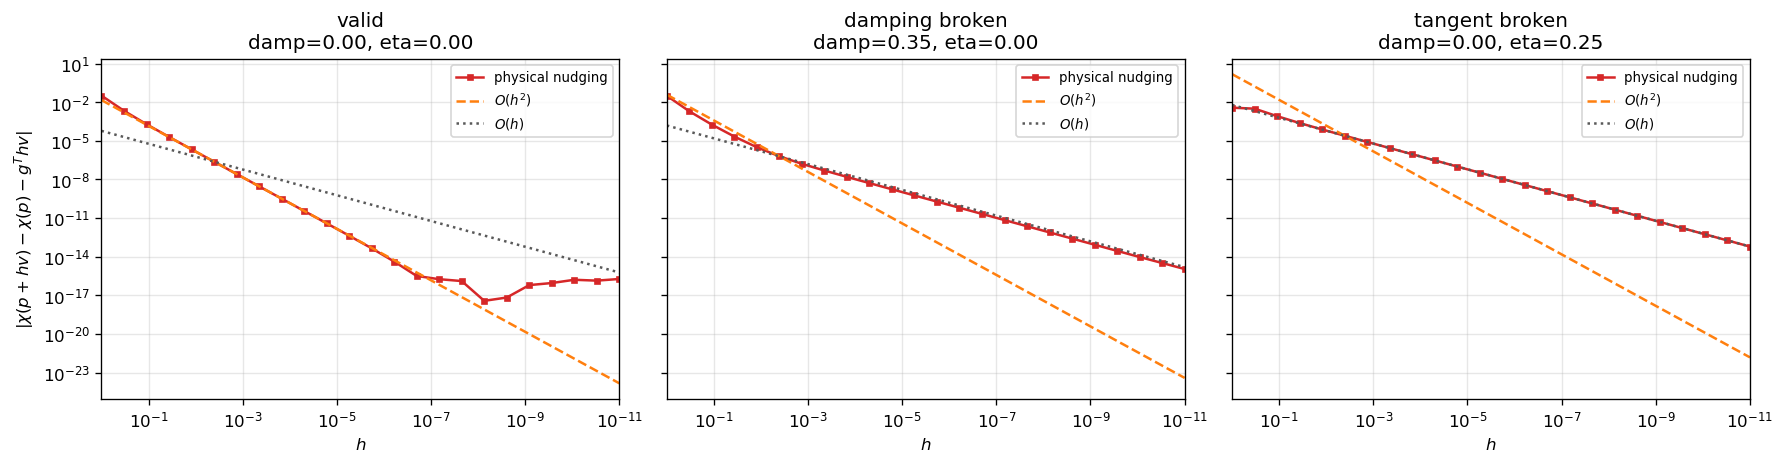

In [7]:
rng = np.random.default_rng(5)
direction = rng.normal(size=len(parameter_names))
direction = direction / np.linalg.norm(direction)
h_values = np.logspace(0, -11, 24)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, result in zip(axes, cases):
    errors = taylor_errors(
        result["p"],
        {"physical nudging": result["grad_physical"]},
        h_values,
        direction,
    )
    anchor = 5
    ref2 = errors["physical nudging"][anchor] * (h_values / h_values[anchor]) ** 2
    ref1 = errors["physical nudging"][anchor] * (h_values / h_values[anchor])

    ax.loglog(h_values, errors["physical nudging"], "s-", ms=3, color="tab:red", label="physical nudging")
    ax.loglog(h_values, ref2, "--", color="tab:orange", label=r"$O(h^2)$")
    ax.loglog(h_values, ref1, ":", color="0.35", label=r"$O(h)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$h$")
    ax.set_title(
        f"{result['label']}\n"
        f"damp={unpack(result['p'])['damp']:.2f}, eta={unpack(result['p'])['eta']:.2f}"
    )
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|\chi(p+h v)-\chi(p)-g^T h v|$")
plt.tight_layout()
plt.show()


### Nudging-amplitude sweep
We repeat the physical run for $\epsilon$ from $10^{-1}$ to $10^{-9}$.
- In the valid case the error falls as $O(\epsilon)$, the linearization error of a one-sided difference, until roundoff takes over.
- In the broken cases the error levels off at order one. The mismatch is structural, so making $\epsilon$ smaller does not fix it.

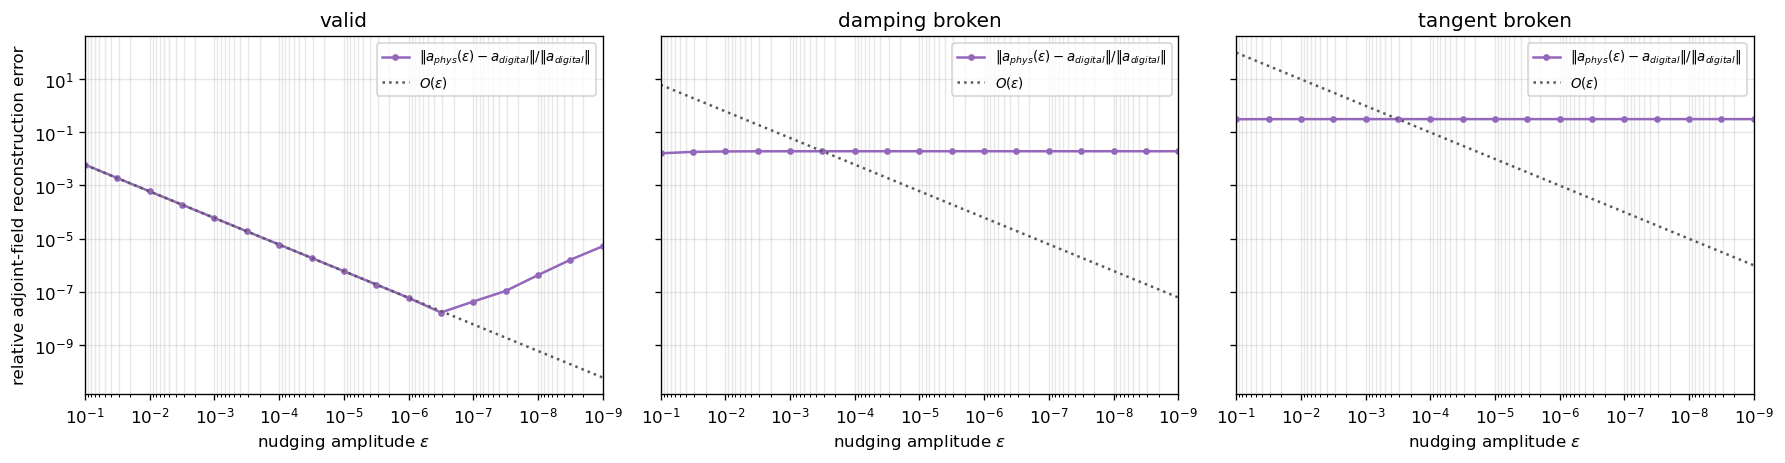

In [8]:
epsilon_values = np.logspace(-1, -9, 17)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, result in zip(axes, cases):
    digital = result["digital"]
    reconstruction_errors = []
    for epsilon in epsilon_values:
        physical = physical_nudged_adjoint(result["p"], result["forward"], epsilon=epsilon)
        reconstruction_errors.append(field_reconstruction_error(digital, physical))

    reconstruction_errors = np.array(reconstruction_errors)
    anchor = 5
    ref1 = reconstruction_errors[anchor] * (epsilon_values / epsilon_values[anchor])

    ax.loglog(
        epsilon_values,
        reconstruction_errors,
        "o-",
        ms=3,
        color="tab:purple",
        label=r"$\|a_{phys}(\epsilon)-a_{digital}\|/\|a_{digital}\|$",
    )
    ax.loglog(epsilon_values, ref1, ":", color="0.35", label=r"$O(\epsilon)$")
    ax.set_xlim(epsilon_values[0], epsilon_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"nudging amplitude $\epsilon$")
    ax.set_title(result["label"])
    ax.legend(fontsize=8)

axes[0].set_ylabel("relative adjoint-field reconstruction error")
plt.tight_layout()
plt.show()


### Control: Taylor test of the digital adjoint
The exact adjoint should give an $h^2$ slope in all three cases. That confirms the forward model, cost derivatives, and overlap formulas.

<string>:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


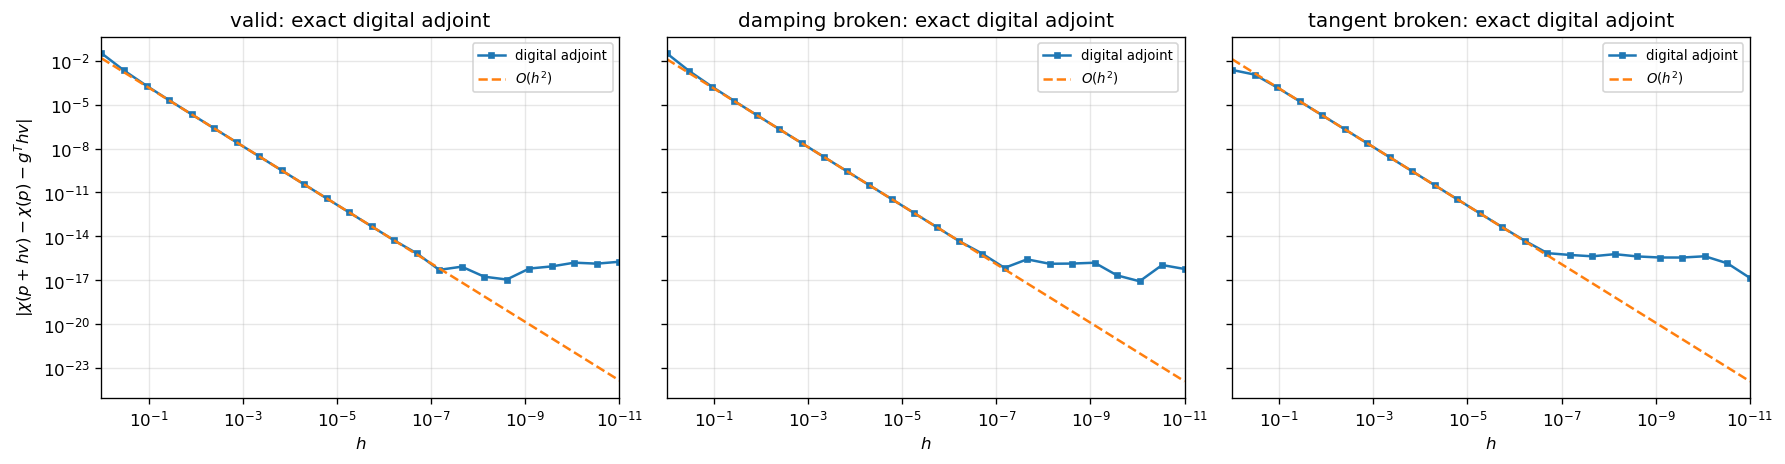

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, result in zip(axes, cases):
    errors = taylor_errors(
        result["p"],
        {"digital adjoint": result["grad_digital"]},
        h_values,
        direction,
    )
    anchor = 5
    ref2 = errors["digital adjoint"][anchor] * (h_values / h_values[anchor]) ** 2

    ax.loglog(h_values, errors["digital adjoint"], "s-", ms=3, color="tab:blue", label="digital adjoint")
    ax.loglog(h_values, ref2, "--", color="tab:orange", label=r"$O(h^2)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlabel(r"$h$")
    ax.set_title(f"{result['label']}: exact digital adjoint")
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"$|\chi(p+h v)-\chi(p)-g^T h v|$")
plt.tight_layout()
plt.show()
